In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv('/car data.csv')

# For Data preview
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner
0,ritz,2014,3.35,5.59,27000,Petrol,Dealer,Manual,0
1,sx4,2013,4.75,9.54,43000,Diesel,Dealer,Manual,0
2,ciaz,2017,7.25,9.85,6900,Petrol,Dealer,Manual,0
3,wagon r,2011,2.85,4.15,5200,Petrol,Dealer,Manual,0
4,swift,2014,4.60,6.87,42450,Diesel,Dealer,Manual,0


In [5]:
# For Cheaking Data types and missing values
print(df.info())

print("\nMissing values check:")
print(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 301 entries, 0 to 300
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Car_Name       301 non-null    object 
 1   Year           301 non-null    int64  
 2   Selling_Price  301 non-null    float64
 3   Present_Price  301 non-null    float64
 4   Driven_kms     301 non-null    int64  
 5   Fuel_Type      301 non-null    object 
 6   Selling_type   301 non-null    object 
 7   Transmission   301 non-null    object 
 8   Owner          301 non-null    int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 21.3+ KB
None

Missing values check:
Car_Name         0
Year             0
Selling_Price    0
Present_Price    0
Driven_kms       0
Fuel_Type        0
Selling_type     0
Transmission     0
Owner            0
dtype: int64


In [8]:
current_year = 2026
df['Car_Age'] = current_year - df['Year']

# 2. Text columns to numbers(Label Encoding)
df.replace({'Fuel_Type':{'Petrol':0, 'Diesel':1, 'CNG':2}}, inplace=True)
df.replace({'Selling_type':{'Dealer':0, 'Individual':1}}, inplace=True)
df.replace({'Transmission':{'Manual':0, 'Automatic':1}}, inplace=True)

# Cheaking New Data
df.head()

,Car_Name,Year,Selling_Price,Present_Price,Driven_kms,Fuel_Type,Selling_type,Transmission,Owner,Car_Age
0,ritz,2014,3.35,5.59,27000,0,0,0,0,12
1,sx4,2013,4.75,9.54,43000,1,0,0,0,13
2,ciaz,2017,7.25,9.85,6900,0,0,0,0,9
3,wagon r,2011,2.85,4.15,5200,0,0,0,0,15
4,swift,2014,4.60,6.87,42450,1,0,0,0,12


In [9]:
X = df.drop(['Car_Name', 'Selling_Price'], axis=1)
y = df['Selling_Price']

print("Questions (X):")
print(X.head())

Questions (X):
   Year  Present_Price  Driven_kms  Fuel_Type  Selling_type  Transmission  \
0  2014           5.59       27000          0             0             0   
1  2013           9.54       43000          1             0             0   
2  2017           9.85        6900          0             0             0   
3  2011           4.15        5200          0             0             0   
4  2014           6.87       42450          1             0             0   

   Owner  Car_Age  
0      0       12  
1      0       13  
2      0        9  
3      0       15  
4      0       12  


In [10]:
from sklearn.model_selection import train_test_split

# 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Training data size: {X_train.shape}")
print(f"Testing data size: {X_test.shape}")

Training data size: (240, 8)
Testing data size: (61, 8)


In [11]:
from sklearn.ensemble import RandomForestRegressor

# 1. Model(instance)
model = RandomForestRegressor(n_estimators=100, random_state=42)

# 2. Model training
model.fit(X_train, y_train)

print("Model trained.")

Model trained.


In [12]:
# Model Testing
y_pred = model.predict(X_test)

# First 5 predictions and actual prices checking
print("AI predictions (first 5):", y_pred[:5])
print("Actual Prices:", y_test[:5].values)

AI predictions (first 5): [ 0.4454 11.0448  4.9015  0.217   7.79  ]
Actual Prices: [ 0.35 10.11  4.95  0.15  6.95]


In [13]:
from sklearn.metrics import r2_score

# calculating R2 score
score = r2_score(y_test, y_pred)

print(f"Model R2 Score: {score}")
print(f"Accuracy (in Percent): {score * 100:.2f}%")

Model R2 Score: 0.9625891427383945
Accuracy (in Percent): 96.26%


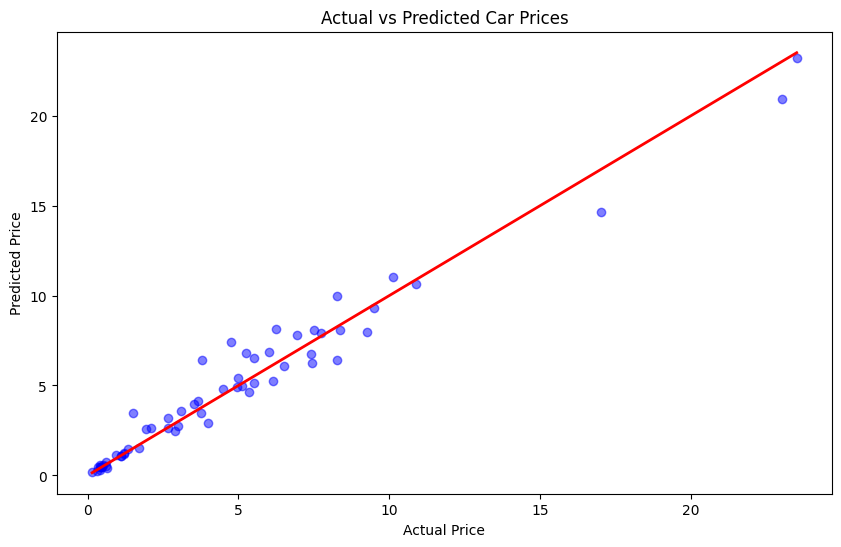

In [14]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue', alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', lw=2)
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title('Actual vs Predicted Car Prices')
plt.show()